In [ ]:
#Carga de datos
import pandas as pd
import numpy as np
from comun.Server_PD import download_dataframe_minio
from comun.get_keys import get_keys

from collections import Counter
import re

#Graficas
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

from itertools import combinations
import ast

import comun.analisisutils as utils


# Carga de datos

In [ ]:
from comun.Server_PD import download_dataframe_minio
from comun.get_keys import get_keys

In [ ]:
# with open("../Private/Claves.json", "r", encoding="utf-8") as archivo:
#     claves = json.load(archivo)

claves = get_keys()

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260309",claves=claves,file_format="parquet")
df.tail()

# Transformamos y añadimos columnas

In [3]:
#Duracion
def iso_a_minutos(iso_duration):
    """"
    Funcion que convierte la duracion a minutos
    """
    try:
        duracion = isodate.parse_duration(iso_duration)
        return duracion.total_seconds() / 60
    except:
        return 0

df['Duracion'] = df['Duracion'].apply(iso_a_minutos)

In [4]:
#Densidad de habla
df['Palabras_Por_Minuto'] = df.apply(utils.calcular_wpm, axis=1)
df['Palabras_Por_Minuto'] = round(df['Palabras_Por_Minuto'], 2)

# Creamos un diccionario con un df por cada genero

In [5]:
diccionario_generos = utils.division_generos(df)
for clave in diccionario_generos:
    print(clave, ":", len(diccionario_generos[clave]))
    df = diccionario_generos[clave]
    df_Adult, df_Kids = utils.division_edad(df)
    print(f'    Adultos: {len(df_Adult)}')
    print(f'    Kids: {len(df_Kids)}')
#Los 0 se deben a que youtube Kids y youtube Movies

Film & Animation : 2666
    Adultos: 634
    Kids: 2032
Autos & Vehicles : 340
    Adultos: 241
    Kids: 99
Music : 2632
    Adultos: 1108
    Kids: 1524
Pets & Animals : 489
    Adultos: 154
    Kids: 335
Sports : 1241
    Adultos: 298
    Kids: 943
Short Movies : 0
    Adultos: 0
    Kids: 0
Travel & Events : 429
    Adultos: 318
    Kids: 111
Gaming : 1610
    Adultos: 652
    Kids: 958
Videoblogging : 0
    Adultos: 0
    Kids: 0
People & Blogs : 3784
    Adultos: 2957
    Kids: 827
Comedy : 73
    Adultos: 48
    Kids: 25
Entertainment : 4470
    Adultos: 1328
    Kids: 3142
News & Politics : 3845
    Adultos: 3820
    Kids: 25
Howto & Style : 2049
    Adultos: 877
    Kids: 1172
Education : 6323
    Adultos: 1795
    Kids: 4528
Science & Technology : 1123
    Adultos: 778
    Kids: 345
Nonprofits & Activism : 281
    Adultos: 131
    Kids: 150
Movies : 0
    Adultos: 0
    Kids: 0
Anime/Animation : 0
    Adultos: 0
    Kids: 0
Action/Adventure : 0
    Adultos: 0
    Kids: 0
Clas

Vemos que hay muchos generos que no tienen ninguna aparicion. No los vamos a tener en cuenta para hacer las graficas.

In [6]:
print("Cantidad de generos sin filtrar:", len(diccionario_generos))

diccionario_generos = dict(filter(lambda item: len(item[1]) > 0, diccionario_generos.items()))

print("Cantidad de generos filtrados:", len(diccionario_generos))


Cantidad de generos sin filtrar: 31
Cantidad de generos filtrados: 15


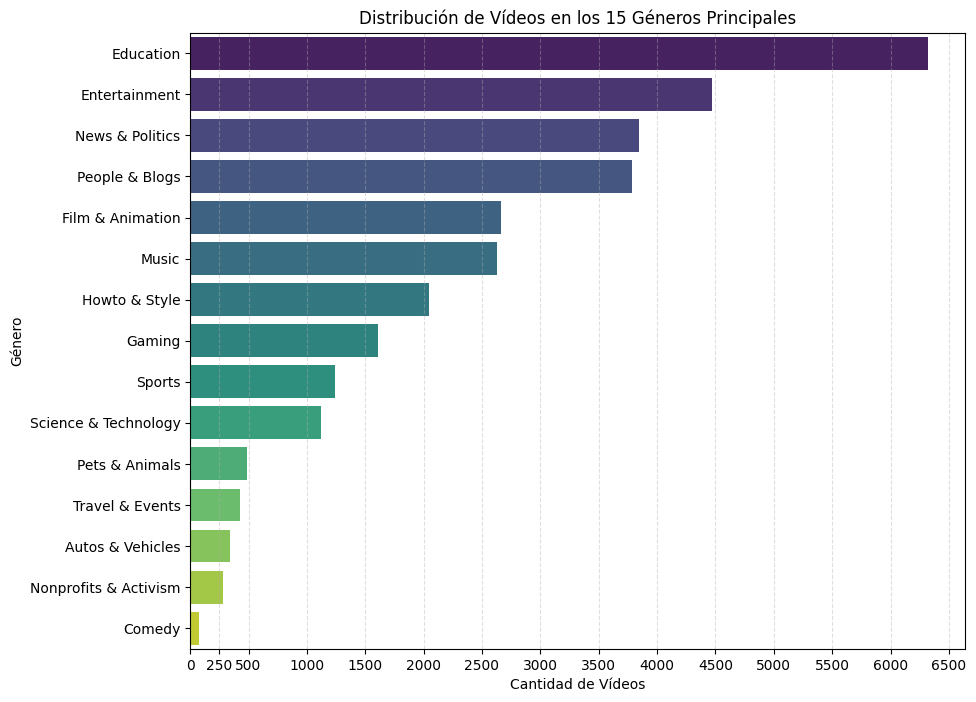

In [7]:
#Frecuencias
generos_nombres = list(diccionario_generos.keys())
frecuencias = [len(df) for df in diccionario_generos.values()]

#Ordenamos
datos_ordenados = pd.Series(frecuencias, index=generos_nombres).sort_values(ascending=False)

#Grafica
plt.figure(figsize=(10, 8))
sns.barplot(x=datos_ordenados.values, y=datos_ordenados.index, palette='viridis')
#Ticks
max_frecuencia = datos_ordenados.max()
tus_ticks = [0, 250, 500]

paso_automatico = 200 if max_frecuencia < 2000 else 500
ticks_automaticos = list(range(0, int(max_frecuencia) + paso_automatico, paso_automatico))

ticks_finales = sorted(list(set(tus_ticks + ticks_automaticos)))
plt.xticks(ticks_finales)


plt.title("Distribución de Vídeos en los 15 Géneros Principales")
plt.xlabel("Cantidad de Vídeos")
plt.ylabel("Género")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

Nos quedamos con 15 géneros con videos.

El genero más frecuente es "Education" con diferencia. Le sigue "Entertaainment". Se podría decir que son las dos categorías más generales. Cualquier video se puede intentar clasificar como "Education" o "Entertaainment", por lo que tiene sentido que aparezcan con más frecuencia. Otros géneros bastante comunes son "News & Politics", "People & Blogs", "Film & Animation" entre otros.

 De esos 15 vamos a trabajar con los 8 mas frecuentes a la hora de analizar los datos.

In [8]:
claves_ordenadas = sorted(diccionario_generos, key=lambda k: len(diccionario_generos[k]), reverse=True)

generos_seleccionados = claves_ordenadas[:8]

diccionario_top = {k: diccionario_generos[k] for k in generos_seleccionados}

print(f"Top 8 generos mas frecuentes: {list(diccionario_top.keys())}")

Top 8 generos mas frecuentes: ['Education', 'Entertainment', 'News & Politics', 'People & Blogs', 'Film & Animation', 'Music', 'Howto & Style', 'Gaming']


Filtramos también los df en funcion a si tienen subtitulos o no

In [9]:
diccionario_subs = {
    clave: df[df['Subtitulos'].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)].copy() 
    for clave, df in diccionario_top.items()
}

for clave in diccionario_subs:
    print(f"{clave}: {len(diccionario_subs[clave])} vídeos con subtítulos.")

Education: 6323 vídeos con subtítulos.
Entertainment: 4470 vídeos con subtítulos.
News & Politics: 3845 vídeos con subtítulos.
People & Blogs: 3784 vídeos con subtítulos.
Film & Animation: 2666 vídeos con subtítulos.
Music: 2632 vídeos con subtítulos.
Howto & Style: 2049 vídeos con subtítulos.
Gaming: 1610 vídeos con subtítulos.


# Análisis no textual

## Duracion

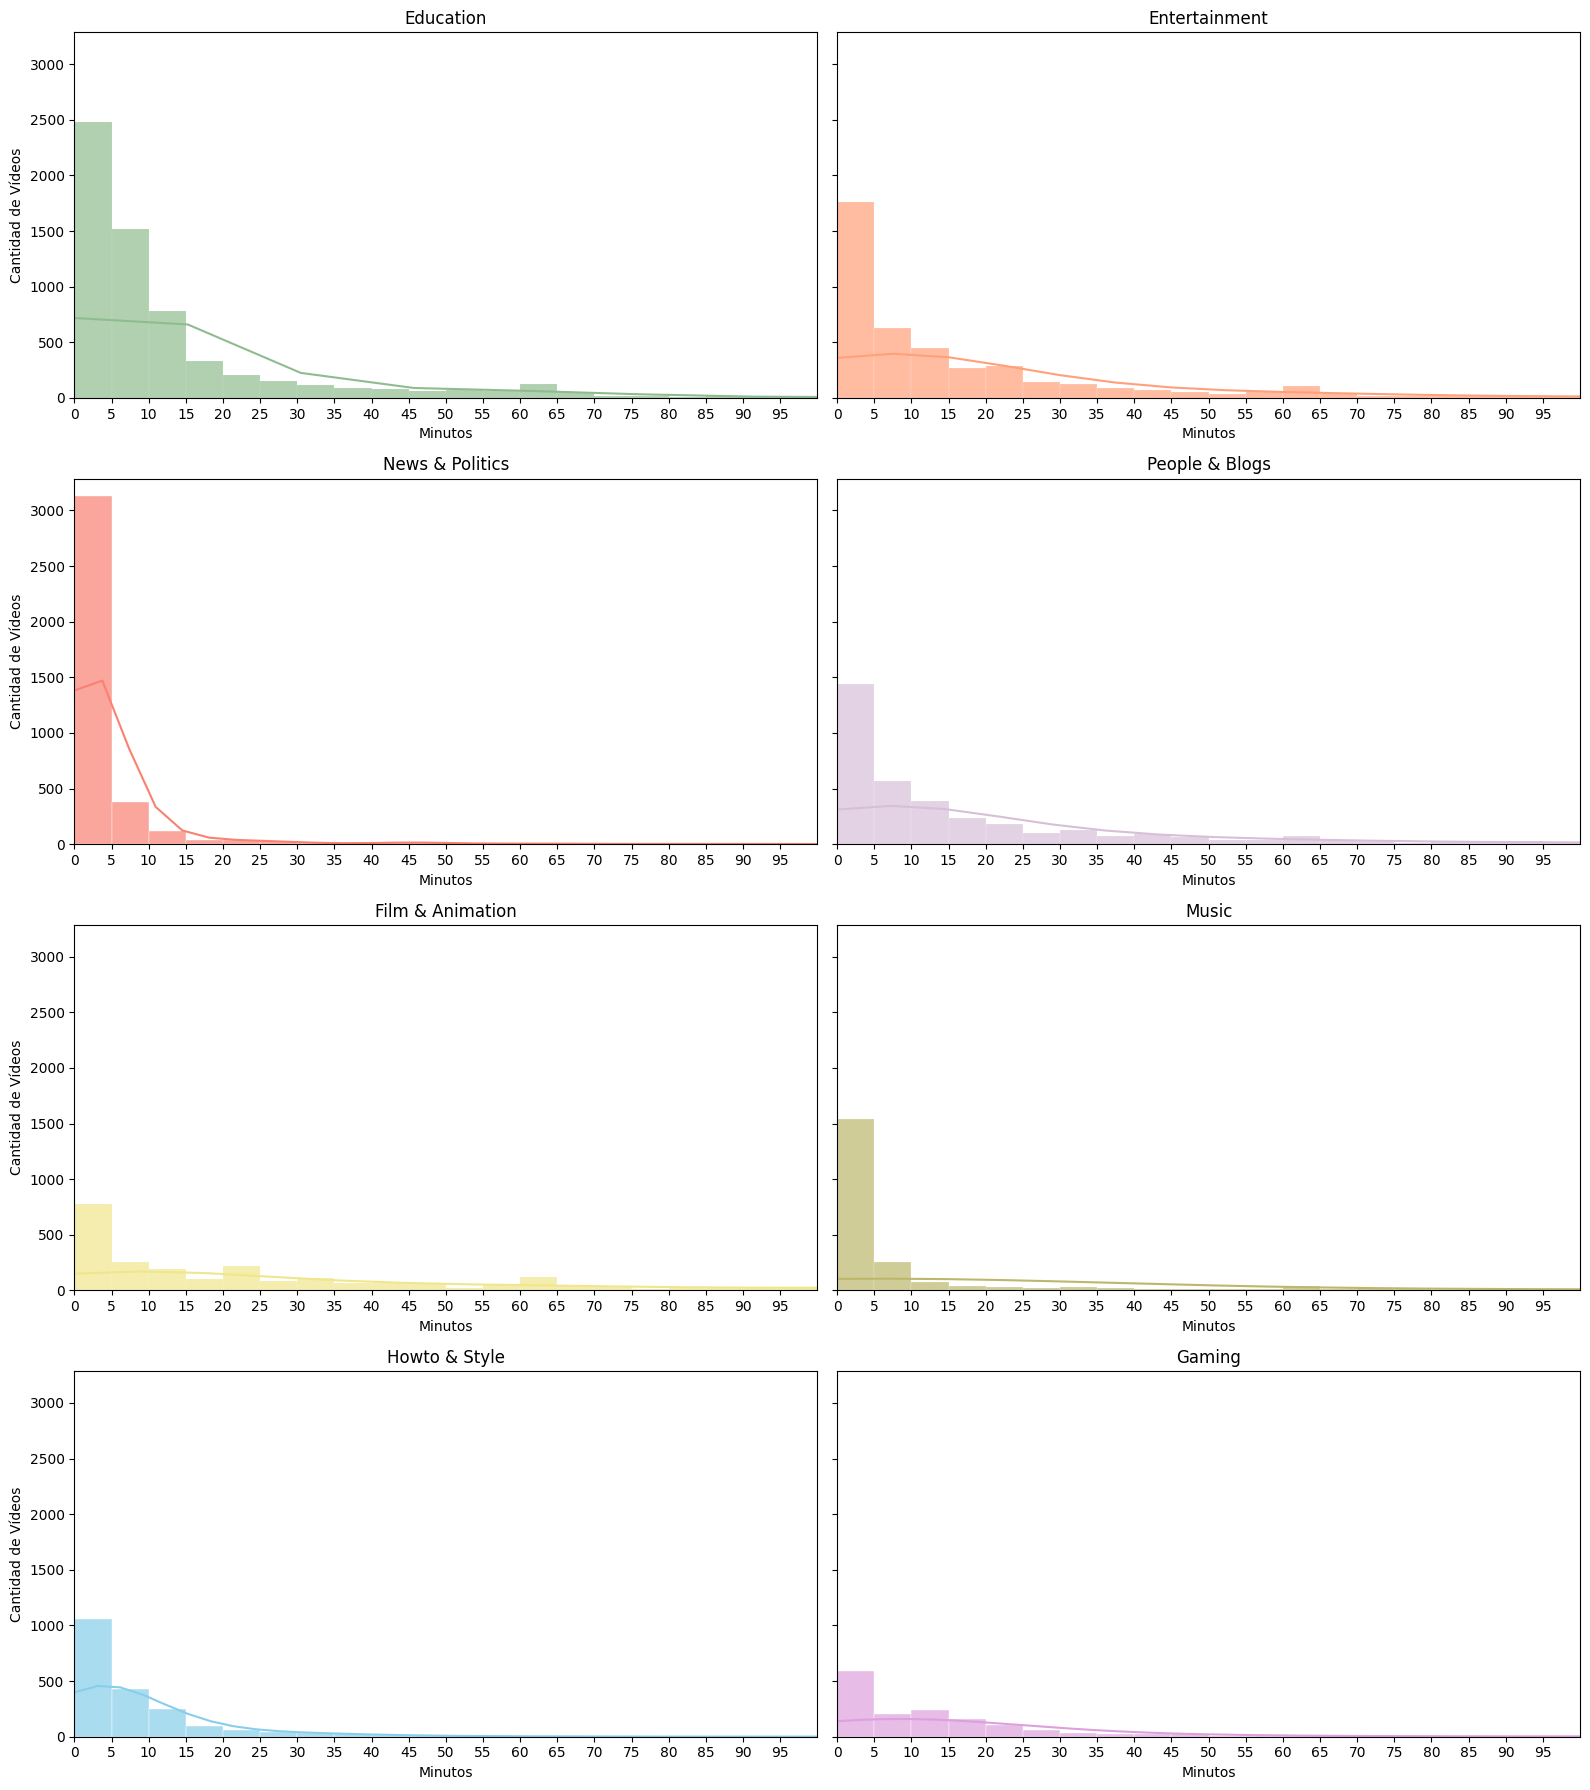

In [10]:
# Configuración
fig, ax = plt.subplots(4, 2, figsize=(16, 18), sharey=True)

ax = ax.flatten()
colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki', 'skyblue', 'plum']

for i, clave in zip(range(0,8), diccionario_top):
    utils.graficar_histograma_duracion(diccionario_top[clave], clave, ax[i], colores[i])

plt.tight_layout()
plt.show()

Como se puede observar los videos de "Music" y "Politics" tienden a ser más cortos. Concentrandose en duraciones de 5 minutos, a veces 10.
El resto se concentra en duraciones por debajo de 20 minutos, aunque si que tienen más variedad. 
Se puede apreciar como "Education" y "Entertainment" tienen más densidad de datos.

**COMPLETAR**

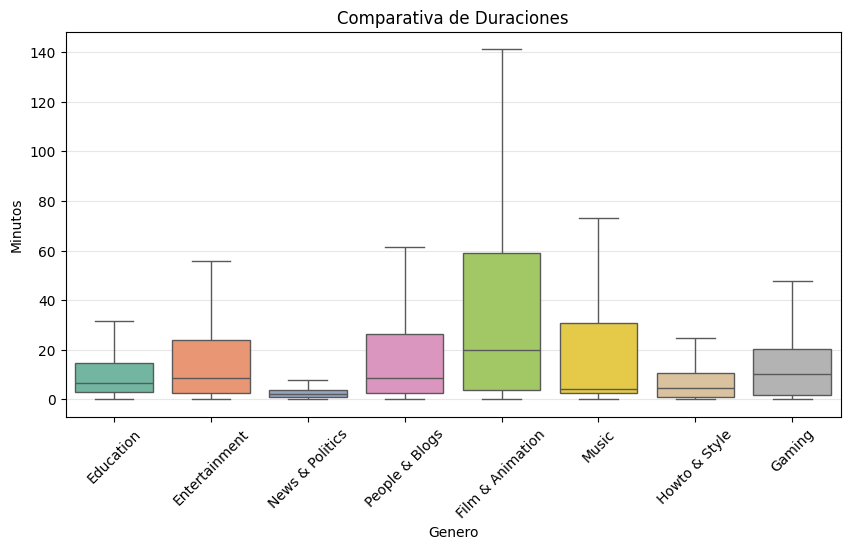

In [11]:
df_grafica = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_top.items()
])

plt.figure(figsize=(10, 5))
sns.boxplot(x='Genero', y='Duracion', data=df_grafica, palette='Set2', showfliers=False)  

plt.xticks(rotation=45)
plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.grid(axis = "y", alpha = 0.3)
plt.show()

En este gráfico podemos comprobar que sin ninguna duda, los videos más largos son los que se clasifican como "Film & Animation". Esto se debe a que la mayoría de videos bajo esta etiqueta serán largometrajes. Se aprecía también un amplio rango intercuartilico, lo que nos hace pensar que, además de peliculas, en esta categoría entran trailers u otro tipo de videos. 

Los videos musicales tienen una mediana muy baja, como era de esperar, pero nos sorprende que el bigote superior es el segundo más alto. Puede ser por videos con musica relajante para estudiar, videos de cine en los que se habla de la banda sonora u orquestas o conciertos.

Las cajas de "Entretainment" y "Gaming" son bastante similares. La diferencia más notable es que los videos de videojuegos suelen ser algo mas largos. Al ser "Entretainment" una categoría más amplia habrá más variabilidad entre los videos. "People & Blogs" también es bastante similar a estas dos.

Nos sorprende ver que "News and Politics" tiene una caja notablemente aplastada, con duraciones inferiores a 5 minutos. Esto puede que sea una estrategia para mantener la atención del espectador en videos complejos.

"Education" tiene una caja bastante estándar que nos hace ver que la mayoría de videos son muy consistentes.

## Densidad de habla

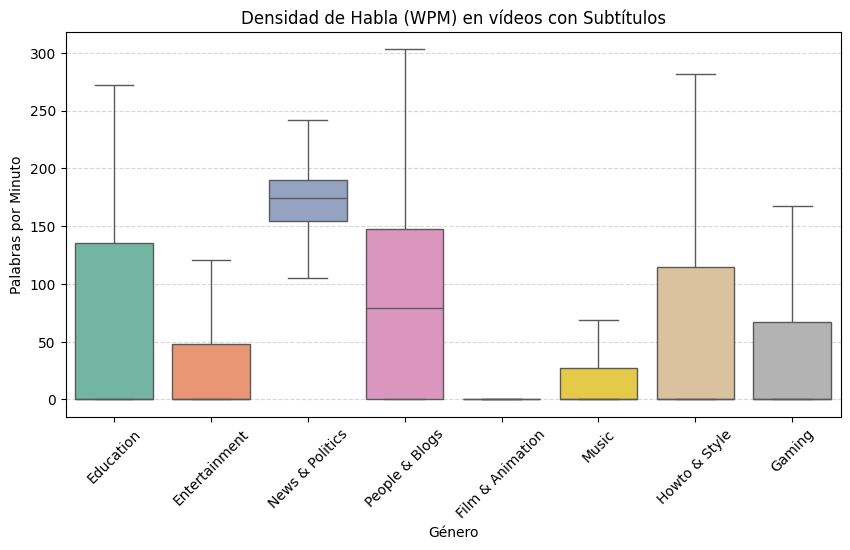

In [12]:
df_grafica_subs = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_subs.items()
])

plt.figure(figsize=(10, 5))

#No mostramos los outliers para que se vea más limpio
sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_grafica_subs, palette='Set2', showfliers=False)


plt.title('Densidad de Habla (WPM) en vídeos con Subtítulos')
plt.xlabel('Género')
plt.ylabel('Palabras por Minuto')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

La caja que más llama la atención de esta grafica posiblement es la de "News & Politics". Se aprecia una densidad de habla notablemente superior al resto. Esto tiene sentido ya que suelen ser videos informativos que quieren hacer llegar un mensaje claro al espectador. Además, como hemos visto antes, suelen ser videos extremadamente cortos por lo que tienen que encajar una gran cantidad de datos en un corto periodo de tiempo.

"People & Blogs" y "Education" tienen tamaños bastante similares. Pero son géneros bastante independientes. No pensamos que haya una relación directa, sino más bien se puede tratar de una casualidad. Podemos ver que la mediana en "Education" es extremadamente baja, y no solo en esta sino también en el resto, excepto en "People & Blogs". 

También destaca que en "Film & Animation" la caja está completamente aplastada. 

Como podemos ver la densidad de habla se ve afectada por la duración de los videos. Cuanto mas cortos son los videos mayor densidad de habla hay. Por eso "News & Politics" tiene una densidad de habla tan alta y "Film & Animation" parece que no tiene.

# Analisis Textual

## Título

In [13]:
diccionario_tf_titulos = {}

for clave, df_genero in diccionario_top.items():
    diccionario_tf_titulos[clave] = utils.tfidf_ngrams_titles(df_genero, "Titulo")


In [39]:
common_terms = utils.common_terms_dictionary(diccionario_tf_titulos, "Titulo")

common_terms.sort_values("Score_Std", ascending=False).head(10)

,Titulo,Score_Education,Score_Entertainment,Score_News & Politics,Score_People & Blogs,Score_Film & Animation,Score_Music,Score_Howto & Style,Score_Gaming,Score_Std,Score_Total
0,kids,157.078476,101.974670,4.617376,26.673143,68.784540,29.002425,16.790025,1.599017,54.778636,406.519673
1,learn,66.426043,18.459963,1.183948,9.354771,11.690796,6.112594,7.229196,1.990696,21.374806,122.448008
2,song,58.468155,23.990555,0.881952,7.312621,16.338878,37.186217,1.505609,2.023670,20.623377,147.707657
10,episode,21.991227,34.459076,1.265999,15.308845,38.285343,2.626615,3.703394,10.656220,14.389660,128.296720
161,official,1.769633,14.573524,2.145635,6.259549,16.162272,42.203621,1.049902,2.580586,13.983922,86.744723
4,video,28.616002,21.812479,11.262500,17.012738,13.066814,42.538190,7.388008,4.742255,12.465385,146.438986
3,2026,38.868654,19.662771,31.219201,33.855110,4.787276,22.647679,13.167086,8.775537,12.328932,172.983314
14,make,20.395924,13.647176,5.777053,14.863338,6.140162,1.724946,35.327796,6.039224,10.901689,103.915618
26,new,14.600471,23.994932,40.868457,19.437536,21.062584,9.471372,12.543351,20.308083,9.621013,162.286785
7,vs,24.630684,22.581669,2.922576,19.107317,11.923691,6.311321,11.192687,27.716290,9.016053,126.386236


La palabra "kids" aparece sobretodo en "Education" y "Entretaiment", con presencía en "Film & Animation". Rara vez aparece en "News & Politics". Todo esto lo hemos podido observar en el analisis de los videos infantiles.

Como era de esperar "Learn" tiene muchas apariciones en "Education".

La palabra "video" aparece equitativamente en todos los génros excepto en "Music" donde tiene mayor peso. Lo mismo pasa con "Official".

Ahora vamos a comparar las palabras que aparecen exclusivamente en un genero de entre dos que son pueden tener solapaciones.

In [15]:
entertainment_only, gaming_only = utils.exclusive_terms(diccionario_tf_titulos["Entertainment"], 
    diccionario_tf_titulos["Gaming"], "Titulo")

print("Gaming")
print(gaming_only.head(5))
print("Entertainment")
print(entertainment_only.head(5))

Gaming
             Titulo     Score
2440    walkthrough  7.233148
1494            mod  7.012912
1500           mode  6.381914
952   geometry dash  6.170012
951        geometry  6.170012
Entertainment
        Titulo      Score
775     blippi  36.257273
1150  cartoons  30.443450
6053     songs  29.466433
6943    videos  25.358972
1136   cartoon  23.417867


Si observamos las palabras exculsivas entre dos generos que tienen cierta relación podemos sacar algunas palabras especificas de cada categoría.

Vemos que algunas palabras exclusivas de Gaming son; "walkthrough", "mod", "geometry dash" (un juego)...

Por otro lado en entretainment tenemos palabras como "cartoons", "songs", "blippi" (personaje infatil)... Estas palabras no son tan características. Seguramente se solapen con "Film & animation" o "Music".

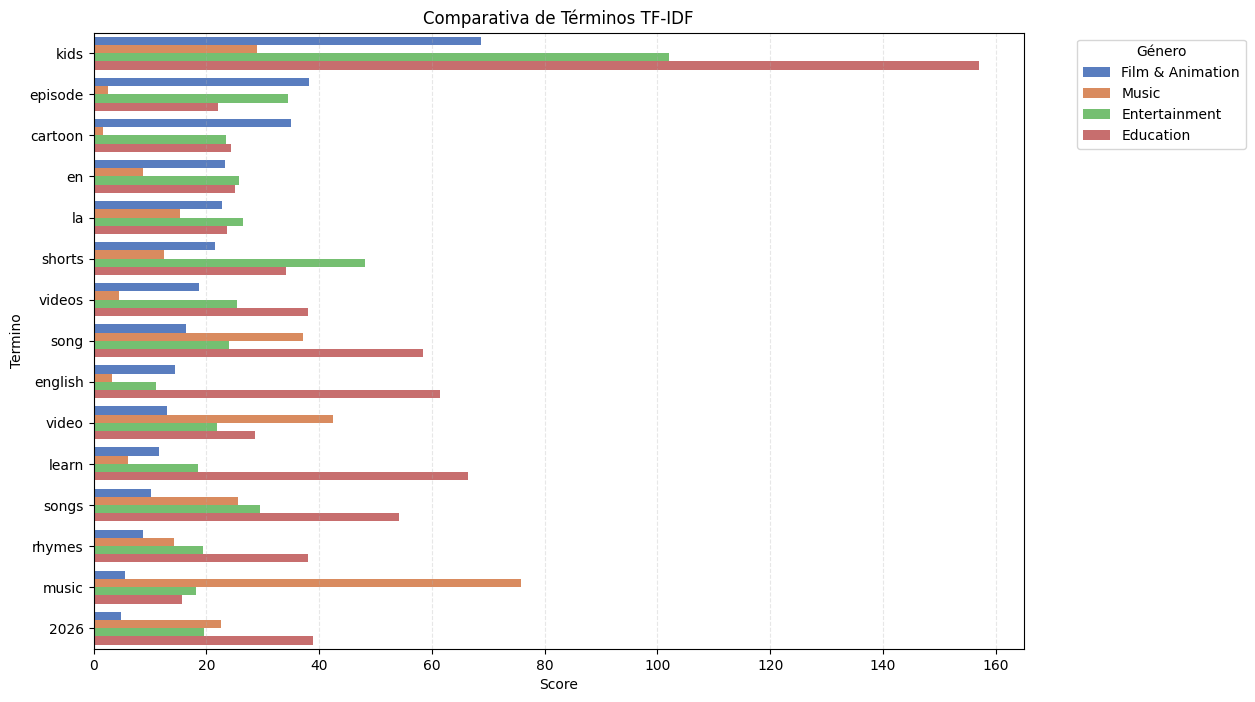

In [16]:
#Seleccionamos 4 generos
generos_a_comparar = ['Film & Animation', 'Music', 'Entertainment', 'Education']

plt.figure(figsize=(12, 8))
utils.comparativa_terminos(generos_a_comparar, diccionario_tf_titulos)
plt.show()


"kids" tiene el puntaje más alto de toda la gráfica dentro de Education.
Palabras como "learn", "english", "song" y "songs" muestran una relevancia masiva en esta categoría, lo que indica un fuerte enfoque en la enseñanza de idiomas y contenido infantil.

En la categoría "Music" como era de esperar, domina el término "music". También tiene una presencia fuerte en los términos "video" y "song", lo que sugiere que su TF-IDF está muy concentrado en etiquetas descriptivas del formato.

"Entertainment" muestra un perfil más equilibrado, pero destaca notablemente en el término "shorts" (superando a todas las demás categorías en esa palabra) y tiene una presencia sólida en "kids".

"Film & Animation" tiene puntuaciones generalmente más bajas y uniformes en comparación con las demás. Sus picos más altos están en "kids", "episode" y "cartoon", lo cual es lógico.


In [17]:
#BERTOPIC SOLUCIONAR
topic_model_titulo, df_bertopic_titulo, temas_bertopic_titulo = utils.analizar_bertopic_dict(diccionario_top, "Titulo")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
dicc_bertopic_titulo = utils.division_generos(df_bertopic_titulo)
claves_ordenadas = sorted(dicc_bertopic_titulo, key=lambda k: len(dicc_bertopic_titulo[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_titulo = {k: dicc_bertopic_titulo[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_titulo:
    print(f'Size of {clave, len(diccionario_top_bertopic_titulo[clave])}')


Size of ('Education', 6323)
Size of ('Entertainment', 4470)
Size of ('News & Politics', 3845)
Size of ('People & Blogs', 3784)
Size of ('Film & Animation', 2666)
Size of ('Music', 2632)
Size of ('Howto & Style', 2049)
Size of ('Gaming', 1610)


<Figure size 1000x600 with 0 Axes>

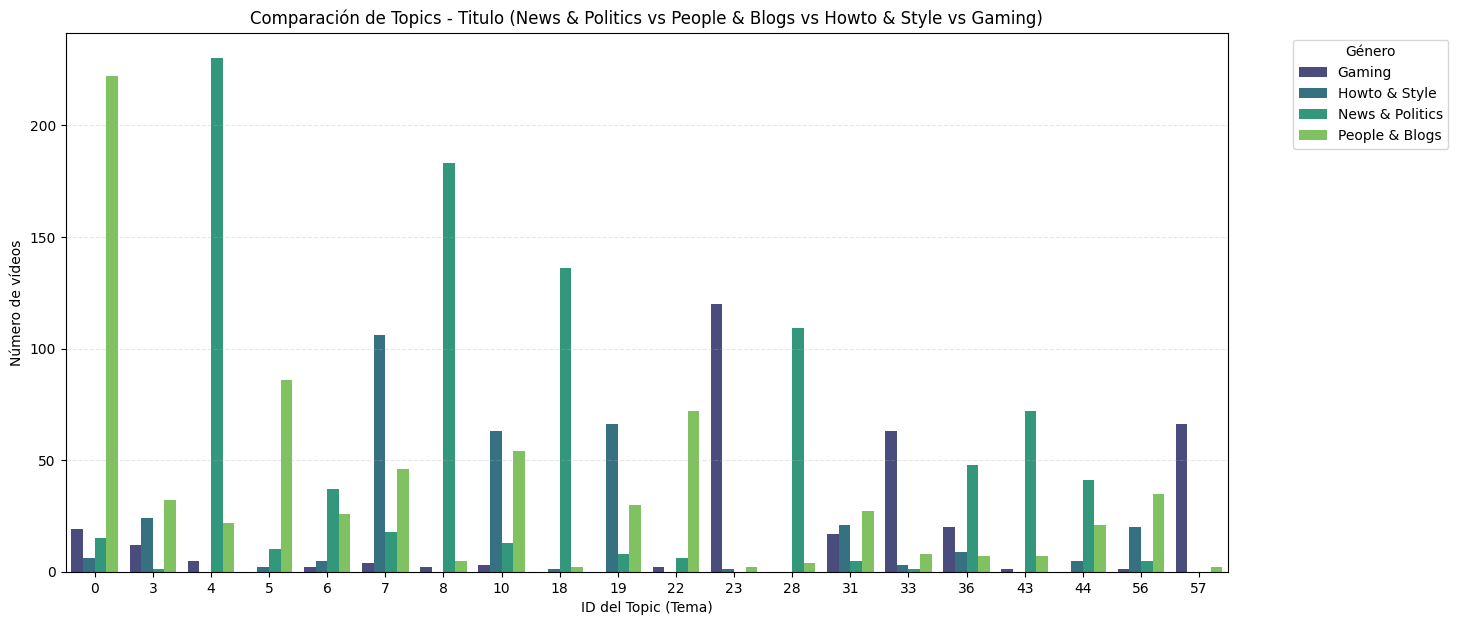

In [19]:
generos_a_comparar = ["News & Politics", "People & Blogs", "Howto & Style", "Gaming"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo, generos_a_comparar, "Titulo")
plt.show()

In [42]:
topic_info = topic_model_titulo.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,12432,-1_the_to_of_in,"[the, to, of, in, and, how, with, song, from, ...",[Twinkle Twinkle Little Star LOOP | Fun Learni...
1,0,602,0_her_ceo_she_he,"[her, ceo, she, he, his, wife, him, me, husban...","[He Left Her in Fire With His Mistress, She Re..."
2,1,531,1_cartoons_cartoon_network_oddbods,"[cartoons, cartoon, network, oddbods, fixies, ...",[FOR SALE! | Mr Bean | Cartoons for Kids | Wil...
3,2,359,2_numberblocks_math_calculus_count,"[numberblocks, math, calculus, count, algebra,...",[Multiplication & Division | Learn to Count | ...
4,3,342,3_español_en_de_el,"[español, en, de, el, jorge, dibujos, animados...",[Jorge el Curioso en Español 🐵 El Plan de Jueg...
5,4,272,4_iran_trump_war_israel,"[iran, trump, war, israel, strikes, us, confli...",[US-Israel war with Iran: Strikes escalate acr...
6,5,266,5_bible_jesus_god_prayer,"[bible, jesus, god, prayer, faith, stories, ps...","[The Armor of God | Stories of the Bible, Jesu..."
7,6,226,6_markets_finance_capital_financial,"[markets, finance, capital, financial, khan, a...",[Shorting stock | Stocks and bonds | Finance &...
8,7,215,7_house_old_ask_home,"[house, old, ask, home, this, room, siding, in...",[How to Clean Vinyl Siding | Ask This Old Hous...
9,8,198,8_weather_forecast_storms_fog,"[weather, forecast, storms, fog, thursday, sho...","[WPRI 12 Weather Forecast 3/4/26: Nice, Dry Th..."


"News & Politics" domina los temas 4 (Guerra) y 8 (Clima).

"People & Blogs" domina el tema 0 (Historias personales/Dramas) y el 5 (Religión).

## Titulo canal


In [20]:
diccionario_tf_titulo_canal = {}

for clave, df_genero in diccionario_top.items():
    diccionario_tf_titulo_canal[clave] = utils.tfidf_ngrams_titles(df_genero, "Titulo_canal")

**Terminos comunes**

In [21]:
common_terms = utils.common_terms_dictionary(diccionario_tf_titulo_canal, "Titulo_canal")

common_terms.sort_values("Score_Std", ascending=False).head(20)

,Titulo_canal,Score_Education,Score_Entertainment,Score_News & Politics,Score_People & Blogs,Score_Film & Animation,Score_Music,Score_Howto & Style,Score_Gaming,Score_Std,Score_Total
0,tv,40.756535,38.604934,64.844596,20.991297,20.414145,11.759065,9.774798,1.789366,20.681041,208.934736
1,channel,24.825330,34.821097,32.992012,11.615658,56.062647,20.146429,6.000000,5.876533,17.101856,192.339705
2,world,19.484479,31.966750,3.501685,13.115040,8.423990,2.991656,7.770555,3.000000,10.119660,90.254155
3,family,3.430555,19.886735,5.609715,19.332639,8.590308,1.395529,9.257900,0.891327,7.464060,68.394709


**Terminos exclusivos**

In [22]:
#Entertainment vs Films & Animation
entertainment_only, films_only = utils.exclusive_terms(diccionario_tf_titulo_canal["Entertainment"], 
    diccionario_tf_titulo_canal["Film & Animation"], "Titulo_canal")

print("Film & Animation")
print(films_only.head(5))
print("Entertainment")
print(entertainment_only.head(5))

Film & Animation
     Titulo_canal      Score
557        fixies  28.000000
1110        peppa  25.063095
1139          pig  24.988550
1113    peppa pig  23.405158
750        katuri  21.000000
Entertainment
     Titulo_canal      Score
1342         lego  36.187759
2335         toys  36.021025
259        blippi  35.228124
1560      mrbeast  34.000000
1358         like  32.133372


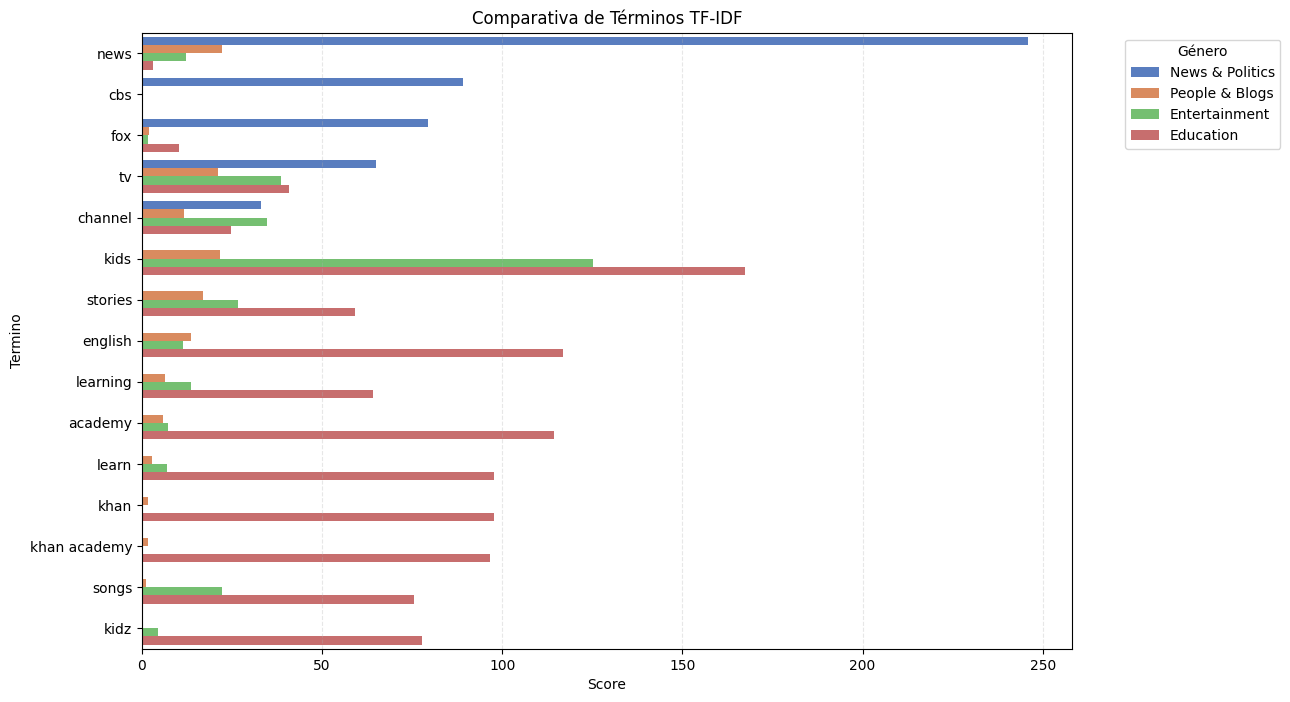

In [23]:
#Seleccionamos 4 generos
generos_a_comparar = ["News & Politics", "People & Blogs", 'Entertainment', 'Education']

plt.figure(figsize=(12, 8))
utils.comparativa_terminos(generos_a_comparar, diccionario_tf_titulo_canal)
plt.show()

In [24]:
topic_model_titulo_canal, df_bertopic_titulo_canal, temas_bertopic_titulo_canal = utils.analizar_bertopic_dict(diccionario_top, "Titulo_canal")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
dicc_bertopic_titulo_canal = utils.division_generos(df_bertopic_titulo_canal)
claves_ordenadas = sorted(dicc_bertopic_titulo_canal, key=lambda k: len(dicc_bertopic_titulo_canal[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_titulo_canal = {k: dicc_bertopic_titulo_canal[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_titulo_canal:
    print(f'Size of {clave, len(diccionario_top_bertopic_titulo_canal[clave])}')


Size of ('Education', 6323)
Size of ('Entertainment', 4470)
Size of ('News & Politics', 3845)
Size of ('People & Blogs', 3784)
Size of ('Film & Animation', 2666)
Size of ('Music', 2632)
Size of ('Howto & Style', 2049)
Size of ('Gaming', 1610)


<Figure size 1000x600 with 0 Axes>

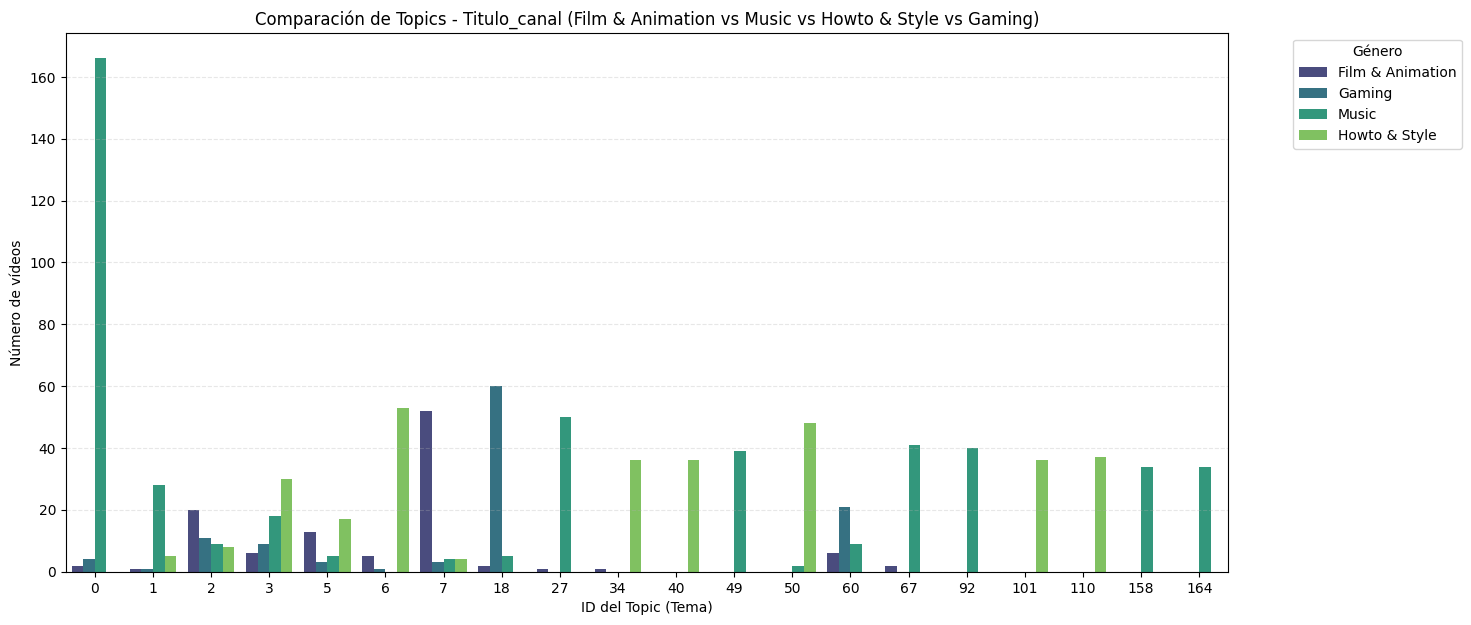

In [26]:
generos_a_comparar = ['Film & Animation', 'Music', "Howto & Style", "Gaming"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo_canal, generos_a_comparar, "Titulo_canal")
plt.show()

In [27]:
topic_info = topic_model_titulo_canal.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4784,-1_tinga_tu_purr_ideas,"[tinga, tu, purr, ideas, aaron, triệu, public,...","[Tick Tock Countdown Timer, Aaron Rheins, Aaro..."
1,0,223,0_music_musicclubkids_camposmusic_concerts,"[music, musicclubkids, camposmusic, concerts, ...","[France Musique concerts, France Musique conce..."
2,1,178,1_wisdom_prayers_god_faith,"[wisdom, prayers, god, faith, church, holy, je...","[Faith Based Wisdom, Prayers, Cross of God Chu..."
3,2,148,2_badanamu_sorcier_pas_est,"[badanamu, sorcier, pas, est, guess, tieu, go,...","[C'est pas sorcier, C'est pas sorcier, C'est p..."
4,3,148,3_linda_claire_briannaplayz_angela,"[linda, claire, briannaplayz, angela, deen, il...","[Paula Deen, Claire Smith, Claire Smith]"
5,4,121,4_health_doctor_dr_healthtree,"[health, doctor, dr, healthtree, bolt, seuss, ...","[Tumble Doctor, Doctors' Circle World's Larges..."
6,5,114,5_tv_más_morphle_recetas,"[tv, más, morphle, recetas, bud, wifr, air, ak...","[Recetas y Más TV, Recetas y Más TV, Recetas y..."
7,6,110,6_calligraphy_nhuan_art_painting,"[calligraphy, nhuan, art, painting, dao, biker...","[Nhuan Dao Calligraphy, Nhuan Dao Calligraphy,..."
8,7,102,7_sonduckfilm_films_cinematic_film,"[sonduckfilm, films, cinematic, film, movies, ...","[SonduckFilm, SonduckFilm, SonduckFilm]"
9,8,100,8_babybus_cartoons_cars_buster,"[babybus, cartoons, cars, buster, supercar, da...","[BabyBus - Kids Songs and Cartoons, BabyBus - ..."


## Tags


In [28]:
diccionario_tf_tags = {}
diccionario_frec_tags = {}
for clave in diccionario_top:
    diccionario_tf_tags[clave] = utils.tfidf_tags(diccionario_top[clave]) 
    diccionario_frec_tags[clave] = utils.frecuencia_tags(diccionario_top[clave])


In [29]:
common_terms = utils.common_terms_dictionary(diccionario_frec_tags, "Tag")
common_terms.sort_values("Frecuencia_Education", ascending=False).head(20)

,Tag,Frecuencia_Education,Frecuencia_Entertainment,Frecuencia_News & Politics,Frecuencia_People & Blogs,Frecuencia_Film & Animation,Frecuencia_Music,Frecuencia_Howto & Style,Frecuencia_Gaming,Score_Std,Score_Total
0,,890,681,846,1308,214,278,388,307,384.400461,4912
1,kids,458,411,1,37,269,86,41,10,187.501190,1313
2,preschool,314,212,1,7,165,46,9,2,120.459833,756
3,learning,283,145,1,7,45,12,43,2,99.287102,538
4,children,281,229,1,16,72,40,8,1,110.853829,648
5,videos for kids,187,206,1,11,93,34,1,1,85.931451,534
6,animation,177,157,1,24,402,24,2,8,141.320242,795
7,family,88,155,2,42,64,26,5,6,52.850193,388
8,video,68,49,354,8,15,29,16,26,116.189424,565
9,videos,53,68,1,2,8,1,11,2,26.628395,146


Mirar que significa yt:cc = on

In [30]:
common_terms = utils.common_terms_dictionary(diccionario_tf_tags, "Tag")

common_terms.sort_values("Score_Std", ascending=False).head(15)

,Tag,Score_Education,Score_Entertainment,Score_News & Politics,Score_People & Blogs,Score_Film & Animation,Score_Music,Score_Howto & Style,Score_Gaming,Score_Std,Score_Total
0,kids,4369.368586,3275.278975,7.964023,372.800206,2143.849601,762.682123,204.486316,46.217061,1671.105472,11182.646890
16,music,363.231701,402.617838,9.631447,334.365711,110.886883,2330.703951,10.948955,27.414866,778.317382,3589.801353
101,news,73.443243,142.306992,2054.847056,136.909158,1.889998,2.339615,1.432267,35.956211,708.954290,2449.124540
1,videos,1538.617211,1114.051670,16.961826,105.776606,543.495445,194.792378,95.818195,42.616720,572.837845,3652.130051
2,english,1417.134042,268.208685,14.331369,100.433510,563.248591,44.824681,14.826128,15.198849,488.013487,2438.205855
3,learning,1317.417753,489.243819,1.453477,46.195823,229.854022,61.740042,81.558772,3.331526,450.132827,2230.795235
4,children,1122.474967,672.877831,6.307545,61.422863,442.708377,255.977430,19.114575,4.803839,404.034712,2585.687427
5,learn,1117.792997,351.832094,4.464711,68.618473,125.404453,77.393471,86.724870,2.537233,375.389752,1834.768302
6,song,955.365827,423.420945,1.184945,52.689518,408.055595,553.349347,7.738185,10.090001,346.513039,2411.894363
7,baby,882.403015,644.722454,5.171448,99.258578,309.802436,180.247497,61.437040,2.898300,324.948045,2185.940767


In [31]:
politics_only, education_only = utils.exclusive_terms(diccionario_frec_tags["News & Politics"], 
    diccionario_frec_tags["Education"], "Tag")

print("News & Politics")
print(politics_only.head(5))
print("Education")
print(education_only.head(5))

News & Politics
             Tag  Frecuencia
3     local news         221
23        news ]         215
24       [ local         171
212      local ]          92
828  syndication          49
Education
                 Tag  Frecuencia
536   nursery rhymes         400
623      kids videos         298
1094        for kids         272
534       kids songs         246
544     kindergarten         239


<Figure size 1000x600 with 0 Axes>

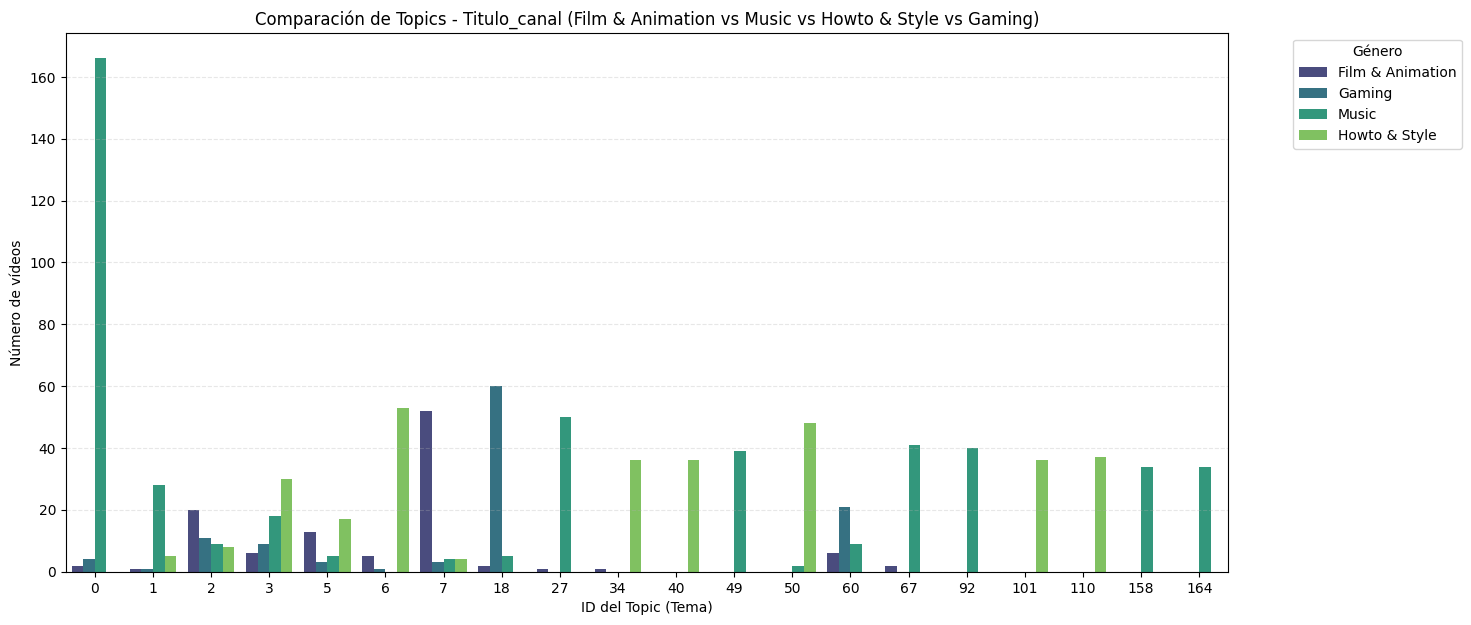

In [32]:
generos_a_comparar = ['Film & Animation', 'Music', "Howto & Style", "Gaming"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo_canal, generos_a_comparar, "Titulo_canal")
plt.show()

## Descripción

In [33]:

topic_model_descripcion, df_bertopic_descripcion, temas_bertopic_descripcion  = utils.analizar_bertopic_dict(diccionario_top, "Descripcion")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
dicc_bertopic_descripcion= utils.division_generos(df_bertopic_descripcion)
claves_ordenadas = sorted(dicc_bertopic_descripcion, key=lambda k: len(dicc_bertopic_descripcion[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_descripcion = {k: dicc_bertopic_descripcion[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_descripcion:
    print(f'Size of {clave, len(diccionario_top_bertopic_descripcion[clave])}')


Size of ('Education', 6161)
Size of ('Entertainment', 4221)
Size of ('News & Politics', 3822)
Size of ('People & Blogs', 3575)
Size of ('Film & Animation', 2647)
Size of ('Music', 2574)
Size of ('Howto & Style', 1956)
Size of ('Gaming', 1558)


<Figure size 1000x600 with 0 Axes>

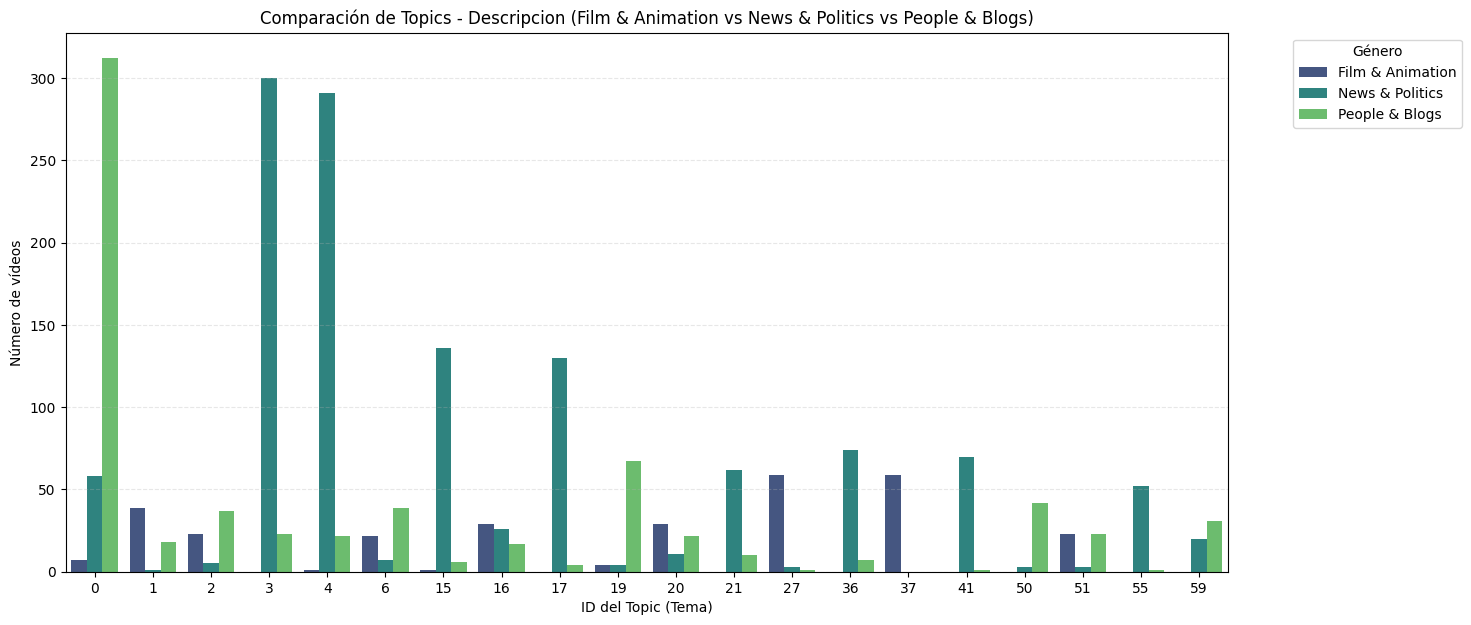

In [35]:
generos_a_comparar = ['Film & Animation', "News & Politics", "People & Blogs"]

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_descripcion, generos_a_comparar, "Descripcion")
plt.show()


## Subtítulos

In [36]:

topic_model_subtitulos, df_bertopic_subtitulos, temas_bertopic_subtitulos  = utils.analizar_bertopic_dict(diccionario_top, "Descripcion")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [37]:
dicc_bertopic_subtitulos= utils.division_generos(df_bertopic_subtitulos)
claves_ordenadas = sorted(dicc_bertopic_subtitulos, key=lambda k: len(dicc_bertopic_subtitulos[k]), reverse=True)

#Volvemos a filtrar el top 8
generos_seleccionados = claves_ordenadas[:8]
diccionario_top_bertopic_subtitulos = {k: dicc_bertopic_subtitulos[k] for k in generos_seleccionados}

for clave in diccionario_top_bertopic_subtitulos:
    print(f'Size of {clave, len(diccionario_top_bertopic_subtitulos[clave])}')


Size of ('Education', 6161)
Size of ('Entertainment', 4221)
Size of ('News & Politics', 3822)
Size of ('People & Blogs', 3575)
Size of ('Film & Animation', 2647)
Size of ('Music', 2574)
Size of ('Howto & Style', 1956)
Size of ('Gaming', 1558)


<Figure size 1000x600 with 0 Axes>

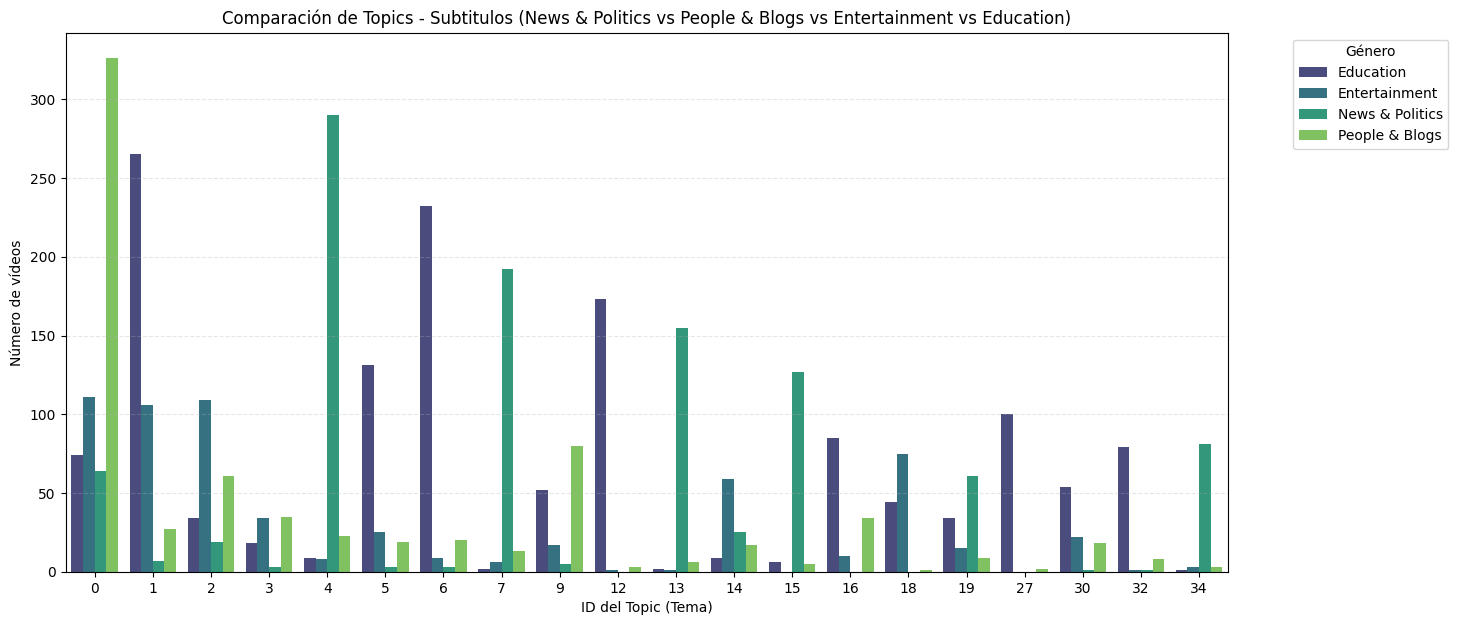

In [38]:
generos_a_comparar = ["News & Politics", "People & Blogs", 'Entertainment', 'Education']

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_subtitulos, generos_a_comparar, "Subtitulos")
plt.show()